https://github.com/iandriyash/ai-arhictect-2026-demo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Включаем строгий стиль оформления с сеткой
sns.set_theme(style="whitegrid")

# Загружаем и объединяем данные
customer = pd.read_csv('customer.csv')
payment = pd.read_csv('payment.csv')
df = payment.merge(customer, on='customer_id')

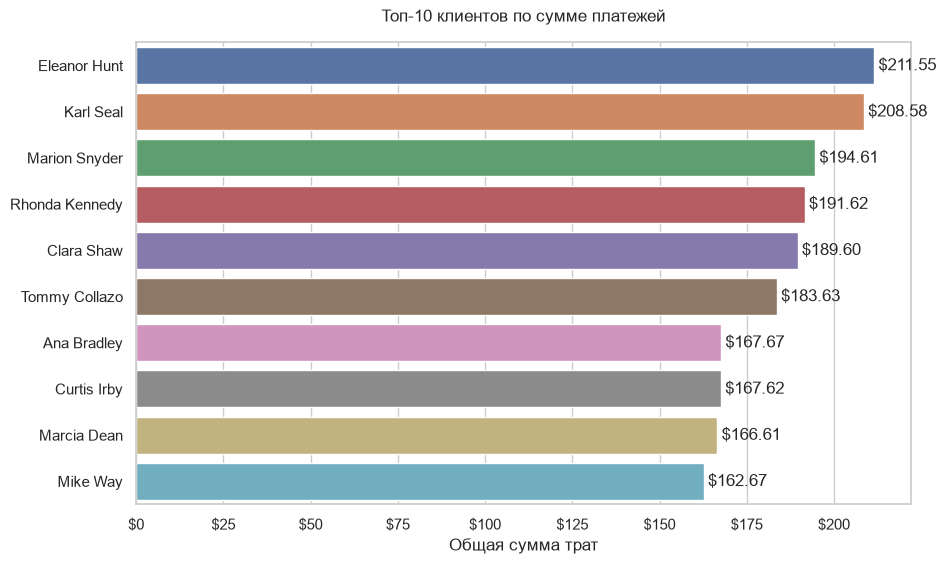

In [9]:
# Подготовка данных
top_10 = df.groupby(['first_name', 'last_name'])['amount'].sum().reset_index()
top_10['full_name'] = top_10['first_name'] + ' ' + top_10['last_name']
top_10 = top_10.sort_values('amount', ascending=False).head(10)

# Построение графика
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_10, x='amount', y='full_name', hue='full_name', palette='deep', legend=False)

# Добавление значений прямо на столбцы
# (цикл по всем контейнерам — при hue='full_name' каждый столбец лежит в своем
# отдельном контейнере, поэтому ax.containers[0] подписал бы только первый бар)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3)

# Форматирование оси X в долларах
formatter = ticker.FormatStrFormatter('$%1.0f')
ax.xaxis.set_major_formatter(formatter)

plt.title('Топ-10 клиентов по сумме платежей', pad=15)
plt.xlabel('Общая сумма трат')
plt.ylabel('')
plt.show()

Горизонтальная ориентация графика позволяет удобно считывать полные имена клиентов без наложения текста. Визуально мы наблюдаем отсутствие резких перепадов в тратах лидеров: переход от первого места ($211.55) к десятому ($162.67) происходит плавно. Это подтверждает высокую однородность покупательской способности в топе и целесообразность применения к ним единой программы лояльности, без внедрения сложных индивидуальных условий.

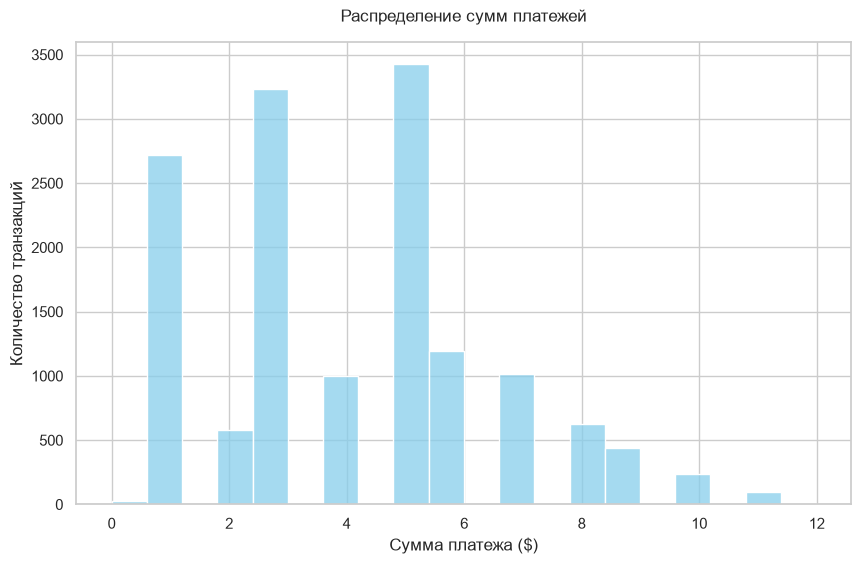

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='amount', bins=20, kde=False, color='skyblue')
plt.title('Распределение сумм платежей', pad=15)
plt.xlabel('Сумма платежа ($)')
plt.ylabel('Количество транзакций')
plt.show()

Построение гистограммы без сглаживающей кривой (параметр kde=False) помогает сфокусироваться на дискретном характере данных. На графике отчетливо выделяются три доминирующих столбца, строго соответствующие нашей тарифной сетке ($0.99, $2.99 и $4.99). Редкие транзакции в правой части (более $8) — это не выбросы в данных, а дорогие премиум-позиции. Вывод: поведение аудитории жестко регулируется базовым прайс-листом, нестандартные суммы практически отсутствуют.

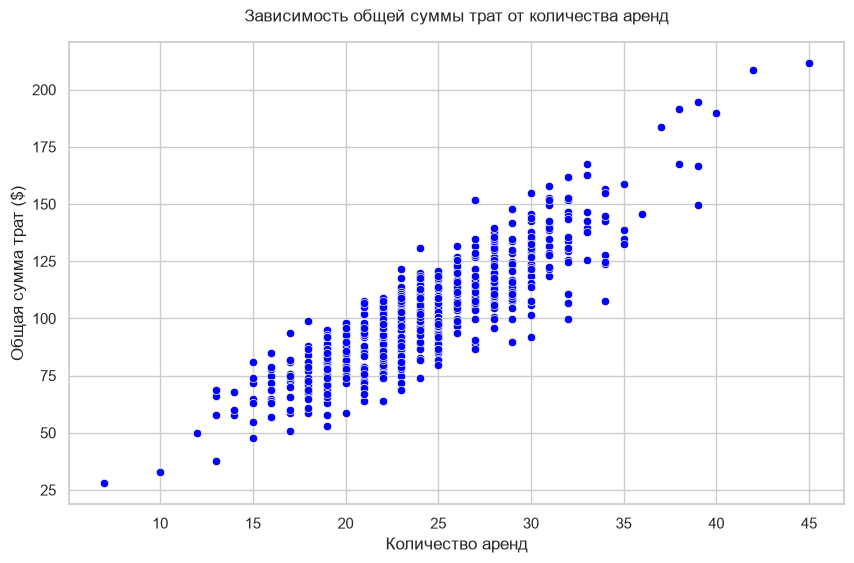

In [5]:
# Агрегация данных
customer_stats = df.groupby('customer_id').agg(
    total_spent=('amount', 'sum'),
    total_rentals=('amount', 'count')
).reset_index()

# Построение графика
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_stats, x='total_rentals', y='total_spent', color='blue')
plt.title('Зависимость общей суммы трат от количества аренд', pad=15)
plt.xlabel('Количество аренд')
plt.ylabel('Общая сумма трат ($)')
plt.show()

Инструмент scatterplot наглядно отображает плотность распределения каждого наблюдения в координатах «частота – выручка». Мы видим монолитное облако точек, вытянутое по диагонали, без формирования отдельных изолированных кластеров (например, нет группы "редких, но сверхбогатых" клиентов). Следовательно, общая выручка предсказуемо растет строго за счет количества аренд, и маркетологам стоит направить усилия именно на стимуляцию частоты покупок.

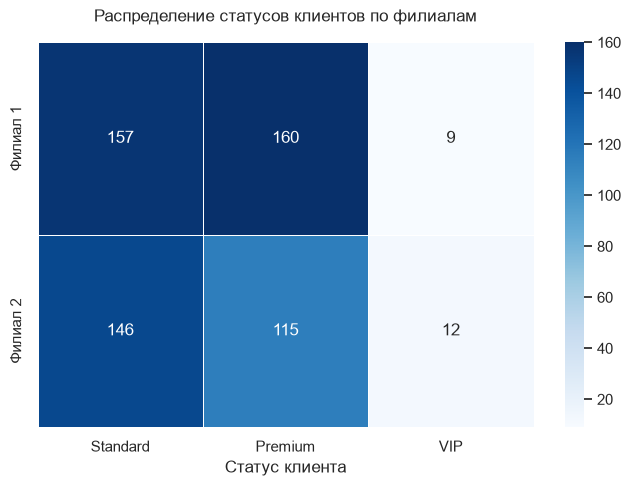

In [6]:
# Добавление филиалов к статистике
customer_stats = customer_stats.merge(customer[['customer_id', 'store_id']], on='customer_id')

# Функция сегментации статусов
def get_status(amount):
    if amount < 100:
        return 'Standard'
    elif amount <= 150:
        return 'Premium'
    else:
        return 'VIP'

customer_stats['status'] = customer_stats['total_spent'].apply(get_status)

# Замена числовых ID на названия
customer_stats['store_name'] = customer_stats['store_id'].replace({1: 'Филиал 1', 2: 'Филиал 2'})

# Формирование матрицы
heatmap_data = pd.crosstab(customer_stats['store_name'], customer_stats['status'])
heatmap_data = heatmap_data[['Standard', 'Premium', 'VIP']] 

# Построение графика
plt.figure(figsize=(8, 5))
sns.heatmap(data=heatmap_data, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Распределение статусов клиентов по филиалам', pad=15)
plt.xlabel('Статус клиента')
plt.ylabel('')
plt.show()

Благодаря функции прямой числовой аннотации ячеек в тепловой карте (annot=True), нам не нужно полагаться только на оттенки цвета — мы видим точные значения статусов. Матрица показывает контринтуитивный факт: хотя Филиал 1 обслуживает больше массовых клиентов (категории Standard и Premium), Филиал 2 обходит его по размеру VIP-сегмента (12 человек против 9). Бизнесу необходимо изучить практики второго магазина (мерчандайзинг, механики апсейла) для трансляции этого успешного опыта на первую точку.